# Homework 5

In [13]:
import numpy as np
import matplotlib.pyplot as plt

## Question 3 (c): simulate map

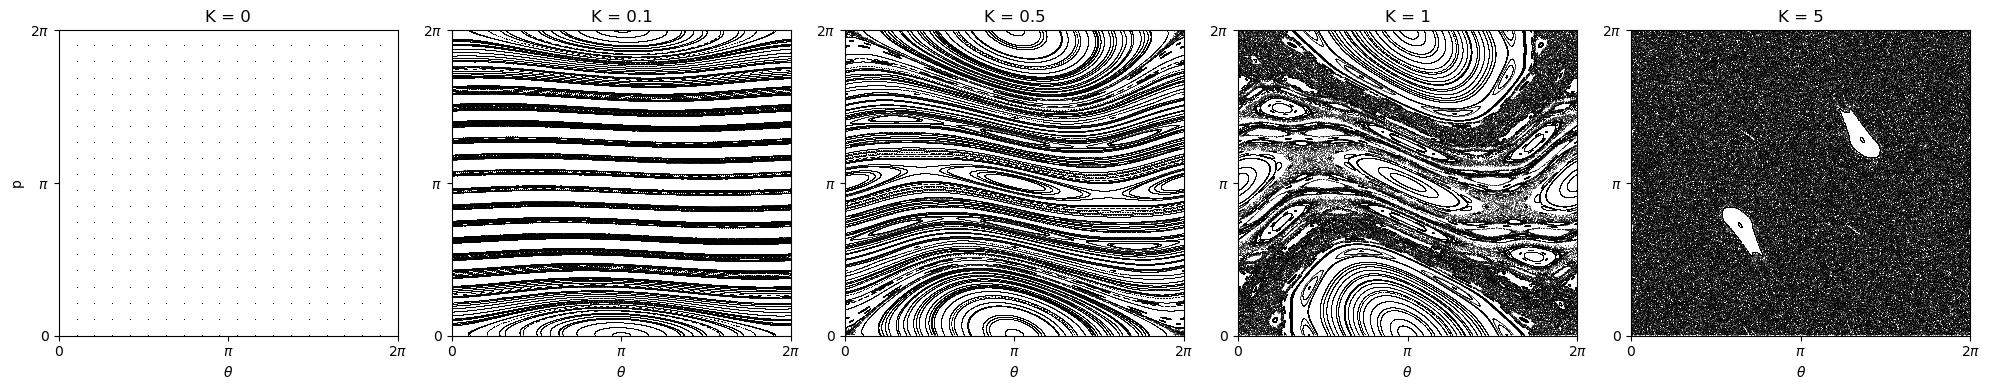

In [14]:
K_values = [0, 0.1, 0.5, 1, 5]
iters = 1000
grid = 20

theta0, p0 = np.meshgrid(np.linspace(0, 2*np.pi, grid), 
                         np.linspace(0, 2*np.pi, grid))
theta0, p0 = theta0.flatten(), p0.flatten()

fig, axes = plt.subplots(1, len(K_values), figsize=(20, 4))

for i, K in enumerate(K_values):
    theta, p = theta0.copy(), p0.copy()
    theta_plot, p_plot = [], []
    
    for _ in range(iters):
        theta_plot.append(theta)
        p_plot.append(p)
        theta = (theta + p) % (2 * np.pi)
        p = (p + K * np.sin(theta)) % (2 * np.pi)
        
    axes[i].plot(theta_plot, p_plot, ',', color='k', alpha=0.5)
    axes[i].set_title(f"K = {K}")
    axes[i].set_xlim(0, 2*np.pi)
    axes[i].set_ylim(0, 2*np.pi)
    axes[i].set_xlabel(r"$\theta$")
    axes[i].set_xticks([0, np.pi, 2*np.pi])
    axes[i].set_xticklabels(["0", r"$\pi$", r"$2\pi$"])
    axes[i].set_yticks([0, np.pi, 2*np.pi])
    axes[i].set_yticklabels(["0", r"$\pi$", r"$2\pi$"])

axes[0].set_ylabel("p")
plt.tight_layout()
plt.show()

/newpage

## Question 3 (d): homoclinic tangle

c:\Users\cvest\anaconda3\envs\mae341\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


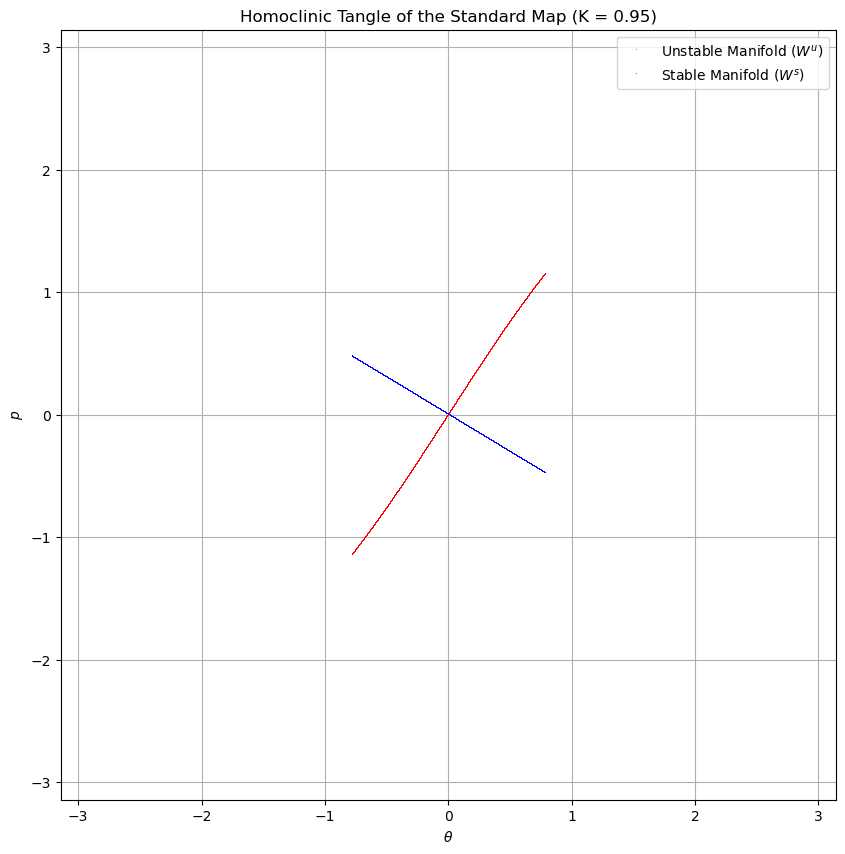

In [15]:
K = 0.95

def wrap(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def map_fwd(th, p):
    th_new = th + p
    p_new = p + K * np.sin(th_new)
    return wrap(th_new), wrap(p_new)

def map_bwd(th, p):
    p_old = p - K * np.sin(th)
    th_old = th - p_old
    return wrap(th_old), wrap(p_old)

lam_u = (2 + K + np.sqrt(K**2 + 4*K)) / 2
lam_s = (2 + K - np.sqrt(K**2 + 4*K)) / 2
vu = np.array([1, lam_u - 1])
vs = np.array([1, lam_s - 1])

eps = 1e-5
pts = 200000
iters = 12

t_u = np.linspace(eps, eps * lam_u, pts)
wu_th = np.concatenate([t_u * vu[0], -t_u * vu[0]])
wu_p = np.concatenate([t_u * vu[1], -t_u * vu[1]])

wu_th_plot, wu_p_plot = [], []
for _ in range(iters):
    wu_th_plot.append(wu_th)
    wu_p_plot.append(wu_p)
    wu_th, wu_p = map_fwd(wu_th, wu_p)

t_s = np.linspace(eps, eps / lam_s, pts)
ws_th = np.concatenate([t_s * vs[0], -t_s * vs[0]])
ws_p = np.concatenate([t_s * vs[1], -t_s * vs[1]])

ws_th_plot, ws_p_plot = [], []
for _ in range(iters):
    ws_th_plot.append(ws_th)
    ws_p_plot.append(ws_p)
    ws_th, ws_p = map_bwd(ws_th, ws_p)

plt.figure(figsize=(10, 10))
plt.plot(np.concatenate(wu_th_plot), np.concatenate(wu_p_plot), ',', color='red', alpha=0.6, label='Unstable Manifold ($W^u$)')
plt.plot(np.concatenate(ws_th_plot), np.concatenate(ws_p_plot), ',', color='blue', alpha=0.6, label='Stable Manifold ($W^s$)')
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p$')
plt.title(f'Homoclinic Tangle of the Standard Map (K = {K})')
plt.grid(True)
legend = plt.legend()
for handle in legend.legend_handles:
    if hasattr(handle, "set_markersize"):
        handle.set_markersize(6)
plt.show()

Not a great success. Even with 20,000 particles there are no folds. Alternative approach: trace invariant manifolds in the lifted map, then project to the torus only for plotting.

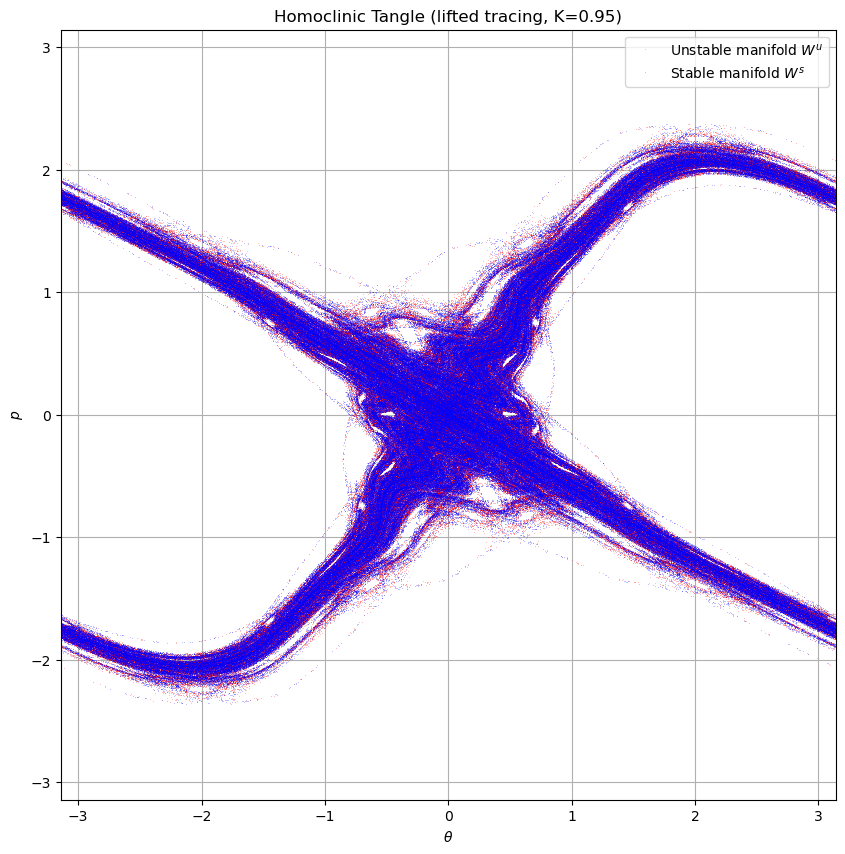

lambda_u=2.559262, lambda_s=0.390738


In [16]:
K = 0.95

def std_map_fwd_lift(theta, p, K):
    theta_new = theta + p
    p_new = p + K * np.sin(theta_new)
    return theta_new, p_new


def std_map_bwd_lift(theta, p, K):
    p_old = p - K * np.sin(theta)
    theta_old = theta - p_old
    return theta_old, p_old


def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi


A = np.array([[1.0, 1.0],
              [K, 1.0 + K]])
vals, vecs = np.linalg.eig(A)
idx_u = np.argmax(np.abs(vals))
idx_s = np.argmin(np.abs(vals))

v_u = np.real(vecs[:, idx_u])
v_s = np.real(vecs[:, idx_s])
v_u = v_u / np.linalg.norm(v_u)
v_s = v_s / np.linalg.norm(v_s)

eps = 1e-7
n_seeds = 2000
n_iter = 260
s = np.linspace(-eps, eps, n_seeds)

theta_u0, p_u0 = s * v_u[0], s * v_u[1]
theta_s0, p_s0 = s * v_s[0], s * v_s[1]

th_u, p_u = theta_u0.copy(), p_u0.copy()
unstable_pts = []
for _ in range(n_iter):
    th_u, p_u = std_map_fwd_lift(th_u, p_u, K)
    unstable_pts.append(np.column_stack((th_u.copy(), p_u.copy())))

th_s, p_s = theta_s0.copy(), p_s0.copy()
stable_pts = []
for _ in range(n_iter):
    th_s, p_s = std_map_bwd_lift(th_s, p_s, K)
    stable_pts.append(np.column_stack((th_s.copy(), p_s.copy())))

U = np.vstack(unstable_pts)
S = np.vstack(stable_pts)

U_th, U_p = wrap_pi(U[:, 0]), wrap_pi(U[:, 1])
S_th, S_p = wrap_pi(S[:, 0]), wrap_pi(S[:, 1])

plt.figure(figsize=(10, 10))
plt.plot(U_th, U_p, ',', color='red', alpha=0.25, label=r'Unstable manifold $W^u$')
plt.plot(S_th, S_p, ',', color='blue', alpha=0.25, label=r'Stable manifold $W^s$')

plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p$')
plt.title(f'Homoclinic Tangle (lifted tracing, K={K})')
plt.grid(True)
legend = plt.legend()
for h in legend.legend_handles:
    if hasattr(h, 'set_markersize'):
        h.set_markersize(6)
plt.show()

print(f"lambda_u={vals[idx_u]:.6f}, lambda_s={vals[idx_s]:.6f}")

Nice tangle!